In [1]:
from RDT import get_rdts
import copy
import at
import numpy as np
ring = at.load_lattice('betamodel.mat', use='betamodel')
# --- Get element indices ---
elements_ind = at.get_refpts(ring, "*")
cor_indices = at.get_refpts(ring, 'S[FIJ]2A*')
Corords = [cor_indices,cor_indices]
used_bpm = at.get_refpts(ring, at.elements.Monitor)
QD3 = at.get_refpts(ring, 'QD3[AE]*')
QF4 = at.get_refpts(ring, 'QF4[ABDE]*')
QD5 = at.get_refpts(ring, 'QD5[BD]*')
combined = np.concatenate((QD3, QF4, QD5))
quad_indices = np.sort(combined)
CAVords = at.get_refpts(ring, at.elements.RFCavity)
skew_ord = at.get_refpts(ring, 'S[HFDIJ]*')
ring_pyloco3 = at.load_lattice('ring_pyloco3.mat', use='ring')

skew_err = []
for i in skew_ord:
    skew_err.append((ring_pyloco3[i].PolynomA[1])*ring_pyloco3[i].Length)

quads_err = []
for i in quad_indices:
    quads_err.append((ring_pyloco3[i].PolynomB[1] - ring[i].PolynomB[1] )*ring_pyloco3[i].Length)

Lattice tune after loco : [0.17218543 0.3477392 ]


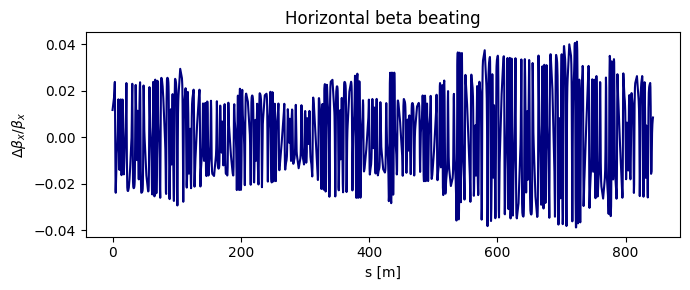

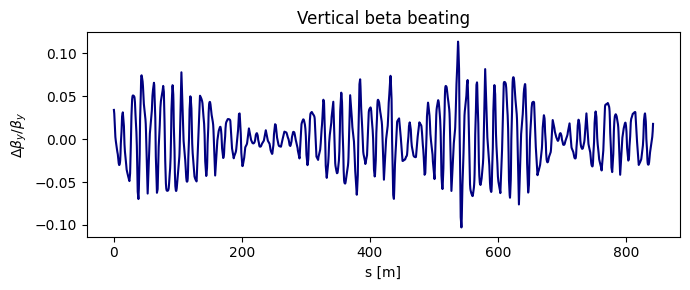

In [2]:
print('Lattice tune after loco :' , at.get_tune(ring_pyloco3))
import matplotlib.pyplot as plt

def plot_data(s_pos, data, xlabel, ylabel, title):
    plt.figure(figsize=(7, 3))
    plt.plot(s_pos, data, color='navy')  # Deep blue color
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    # plt.grid(True, which='both', linestyle=':', color='gray')
    plt.tight_layout()
    plt.show()

_, _, twiss = at.get_optics(ring, elements_ind)
_, _, twiss_err = at.get_optics(ring_pyloco3, elements_ind)
s_pos = twiss_err.s_pos
bx = (twiss_err.beta[:, 0] - twiss.beta[:, 0]) / twiss.beta[:, 0]
by = (twiss_err.beta[:, 1] -  twiss.beta[:, 1]) / twiss.beta[:, 1]
plot_data(s_pos, bx, "s [m]", r"$\Delta\beta_x / \beta_x$ ", "Horizontal beta beating")
plot_data(s_pos, by, "s [m]", r"$\Delta\beta_y / \beta_y$ ", "Vertical beta beating")

In [3]:
numberOfIteration = 5
cut = 96
dcS_rdts = np.zeros(len(skew_ord))

for x in range(numberOfIteration):

    #correct_tune_and_orbit(SC, ORM=ORM, alpha=10)
    #for _ in range(5):
    #  SC.tuning.tune.correct(n_iter=1, gain=0.5,  measurement_method='cheat')
    #SC.tuning.correct_orbit(method = 'svd_values', parameter=1500, n_reps=10, gain=1)

    print("---------------RDT Coupling Corrections---------------")
    [elemdata0, beamdata, elemdata] = at.get_optics(ring, used_bpm)
    dy_c0 = elemdata.dispersion[:, 2]

    F1001C, F1010C, f2000C, f0020C = get_rdts(ring_pyloco3, used_bpm)
    F1001R_c = np.real(F1001C)
    F1001I_c = np.imag(F1001C)
    F1010R_c = np.real(F1010C)
    F1010I_c = np.imag(F1010C)
    difference = np.array([F1001R_c, F1001I_c])
    addit = np.array([F1010R_c, F1010I_c])

    print("err F1001R_c:", F1001R_c[100])
    print("err F1001I_c:", F1001I_c[100])
    print("err F1010R_c:", F1010R_c[100])
    print("err F1010I_c:", F1010I_c[100])

    response_matrix_rdts = np.hstack(
        (np.load('difference_ebs.npy'), np.load('addit_ebs.npy'), np.load('Etay_ebs.npy')))

    u, s, vh = np.linalg.svd(response_matrix_rdts, full_matrices=False)

    F1001C, F1010C, f2000C, f0020C = get_rdts(ring_pyloco3, used_bpm)
    F1001R_c = np.real(F1001C)
    F1001I_c = np.imag(F1001C)
    F1010R_c = np.real(F1010C)
    F1010I_c = np.imag(F1010C)
    difference = np.array([F1001R_c, F1001I_c])
    addit = np.array([F1010R_c, F1010I_c])
    [elemdata0, beamdata, elemdata] = at.get_optics(ring_pyloco3, used_bpm)
    dy_c = elemdata.dispersion[:, 2]
    measured = np.concatenate((difference.flatten(), addit.flatten(), (dy_c - dy_c0)), axis=0)
    dcS = 0 + np.linalg.pinv(response_matrix_rdts.T, rcond=s[cut - 1] / s[0]) @ measured

    for count, ic in enumerate(skew_ord):
        dcS_rdts[count] += dcS[count] * ring_pyloco3[ic].Length
        a = ring_pyloco3[ic].PolynomA[1]
        ring_pyloco3[ic].PolynomA[1] = a - dcS[count]


F1001C, F1010C, f2000C, f0020C = get_rdts(ring_pyloco3, used_bpm)
F1001R_c = np.real(F1001C)
F1001I_c = np.imag(F1001C)
F1010R_c = np.real(F1010C)
F1010I_c = np.imag(F1010C)
print("First element of F1001R_c:", F1001R_c[100])
print("First element of F1001I_c:", F1001I_c[100])
print("First element of F1010R_c:", F1010R_c[100])
print("First element of F1010I_c:", F1010I_c[100])

---------------RDT Coupling Corrections---------------
err F1001R_c: 0.007514425695732548
err F1001I_c: 0.01627541703052848
err F1010R_c: -0.008657453356831601
err F1010I_c: 0.009373548057555114
---------------RDT Coupling Corrections---------------
err F1001R_c: 0.00032666740177468605
err F1001I_c: 0.001073474893140302
err F1010R_c: -0.000347717759493736
err F1010I_c: 0.002207625005165925
---------------RDT Coupling Corrections---------------
err F1001R_c: 0.0011174632382894927
err F1001I_c: 0.0013354086362962236
err F1010R_c: -0.00022833402380204103
err F1010I_c: 0.001663455968437558
---------------RDT Coupling Corrections---------------
err F1001R_c: 0.001086671512866023
err F1001I_c: 0.0013569001571173765
err F1010R_c: -0.00022201832603882462
err F1010I_c: 0.0016311901554386448
---------------RDT Coupling Corrections---------------
err F1001R_c: 0.0010879272126860513
err F1001I_c: 0.0013592850824959881
err F1010R_c: -0.00022149691107754615
err F1010I_c: 0.0016295832553746288
First 

Lattice tune after loco : [0.17231119 0.34760075]


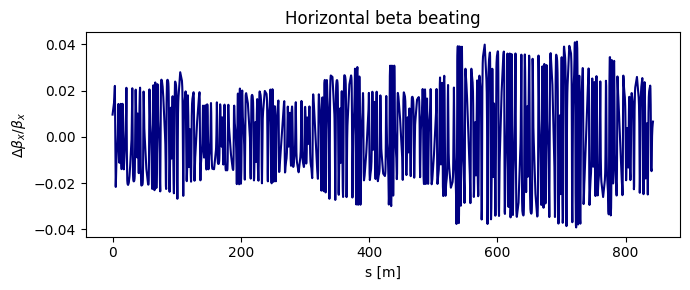

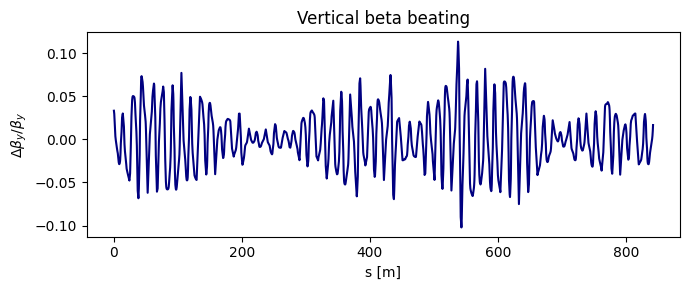

In [4]:
print('Lattice tune after loco :' , at.get_tune(ring_pyloco3))
import matplotlib.pyplot as plt

def plot_data(s_pos, data, xlabel, ylabel, title):
    plt.figure(figsize=(7, 3))
    plt.plot(s_pos, data, color='navy')  # Deep blue color
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    # plt.grid(True, which='both', linestyle=':', color='gray')
    plt.tight_layout()
    plt.show()

_, _, twiss = at.get_optics(ring, elements_ind)
_, _, twiss_err = at.get_optics(ring_pyloco3, elements_ind)
s_pos = twiss_err.s_pos
bx = (twiss_err.beta[:, 0] - twiss.beta[:, 0]) / twiss.beta[:, 0]
by = (twiss_err.beta[:, 1] -  twiss.beta[:, 1]) / twiss.beta[:, 1]
plot_data(s_pos, bx, "s [m]", r"$\Delta\beta_x / \beta_x$ ", "Horizontal beta beating")
plot_data(s_pos, by, "s [m]", r"$\Delta\beta_y / \beta_y$ ", "Vertical beta beating")

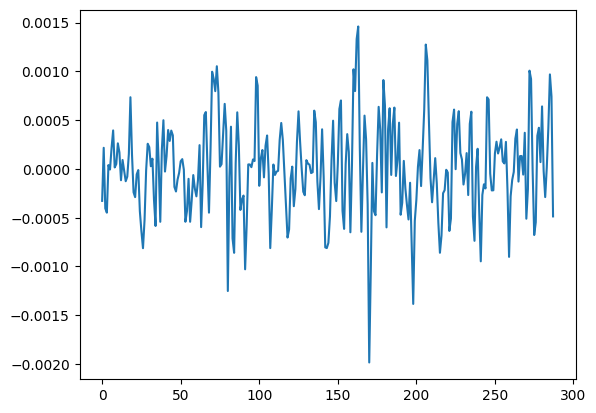

In [7]:
from scipy.io import loadmat
import matplotlib.pyplot as plt
plt.plot(dcS_rdts)
#plt.plot(Skew)